# Lab Assignment - 10

### CS22B1093 Rohan G

---------------------------------

## Environment Setup

In [1]:
# Install required packages
!pip install rouge-score

# Import necessary libraries
import os
import re
import nltk
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
from transformers import BartForConditionalGeneration, BartTokenizer
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm.auto import tqdm

# Download NLTK resources
nltk.download('punkt', quiet=True)

# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Suppress unnecessary CUDA warnings if using GPU
if torch.cuda.is_available():
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning, message=".*cu.*")

# Check CUDA version (optional)
!nvcc --version

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=175824dd65561f5d6563308135f3220c54d4454ed8a072c83cbf493195ac688d
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


2025-04-10 14:16:04.166880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744294564.358184      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744294564.412515      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


## Transformer-Based Models for Text Summarization

### Popular Transformer Models

| Model                | Architecture       | Parameters                          | Max Input Tokens | Suitable Tasks                          | Advantages                                      |
|----------------------|--------------------|-------------------------------------|------------------|-----------------------------------------|------------------------------------------------|
| BART                 | Encoder-Decoder    | 140M (base), 400M (large)          | 1024 tokens      | Summarization, Translation, Text Generation | Strong performance on text generation tasks, especially summarization |
| T5                   | Encoder-Decoder    | 60M (small), 220M (base), 770M (large), 3B (3B), 11B (11B) | 512 tokens | Multiple NLP tasks framed as text-to-text | Versatile for many tasks                     |
| PEGASUS              | Encoder-Decoder    | 568M                               | 1024 tokens      | Abstractive Summarization               | Pre-trained specifically for summarization   |
| GPT-2/3              | Decoder-only       | 124M-175B                          | 1024-2048 tokens | Text Generation, Summarization (extraction) | Strong language generation capabilities      |
| DistilBART           | Encoder-Decoder    | 81M                                | 1024 tokens      | Summarization, Translation              | Smaller version of BART with faster inference |
| ProphetNet           | Encoder-Decoder    | 125M                               | 512 tokens       | Summarization, Question Answering       | Focuses on predicting n-future tokens        |
| LED (Longformer Encoder-Decoder) | Encoder-Decoder | 440M                            | 16,384 tokens    | Long Document Summarization             | Handles longer documents                     |
| BigBird              | Encoder-Decoder    | 126M (base), 381M (large)          | 4,096 tokens     | Long Document Summarization             | Efficient attention mechanism for long texts |

## Selected Model for Fine-tuning

For this project, we'll use `facebook/bart-base` (140M parameters) for the following reasons:

- **Manageable Size**: With 140M parameters, it can be fine-tuned on free compute platforms like Colab/Kaggle.
- **Summarization Performance**: BART was specifically designed with summarization as a key task.
- **Input Length**: Handles up to 1024 tokens, which is sufficient for many news articles.
- **Efficient Training**: The base model offers a good balance between performance and training time/resource requirements.

The base model is more suitable for fine-tuning on limited computational resources compared to larger variants while still providing good summarization capabilities.

## Loading and Exploring Dataset

README.md:   0%|          | 0.00/4.78k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/46.5M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

val.csv:   0%|          | 0.00/3.37M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12565 [00:00<?, ? examples/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

Analyzing train set:   0%|          | 0/1000 [00:00<?, ?it/s]

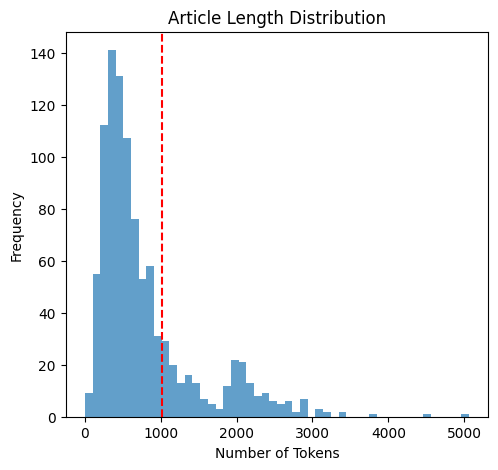

/tmp/ipykernel_19/501199396.py:52: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 2, 2)


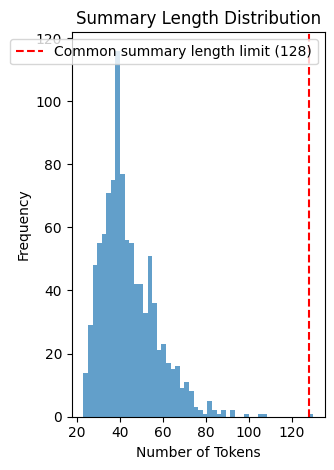


Article length statistics:
Mean: 798.89 tokens
Median: 560.00 tokens
Max: 5064 tokens
Articles exceeding 1024 tokens: 22.60%

Summary length statistics:
Mean: 44.08 tokens
Median: 41.00 tokens
Max: 130 tokens


In [2]:
# Load the ILSUM dataset, English subset
english_dataset = load_dataset("ILSUM/ILSUM-1.0", "English")

# Display dataset information
print(f"Dataset structure: {english_dataset}")
print(f"Available splits: {english_dataset.keys()}")

# Check the number of samples in each split
print(f"Number of samples in train: {len(english_dataset['train'])}")
print(f"Number of samples in validation: {len(english_dataset['validation'])}")
print(f"Number of samples in test: {len(english_dataset['test'])}")

# Examine the first sample to understand the data structure
print("\nSample data point:")
sample = english_dataset['train'][0]
for key, value in sample.items():
    if isinstance(value, str) and len(value) > 100:
        print(f"{key}: {value[:100]}... (truncated)")
    else:
        print(f"{key}: {value}")

# Analyze text length distribution
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

def get_token_lengths(dataset, split):
    article_lengths = []
    summary_lengths = []
    
    for i in tqdm(range(min(1000, len(dataset[split]))), desc=f"Analyzing {split} set"):
        sample = dataset[split][i]
        article_tokens = tokenizer(sample['Article'], truncation=False, return_tensors="pt")
        summary_tokens = tokenizer(sample['Summary'], truncation=False, return_tensors="pt")
        
        article_lengths.append(len(article_tokens.input_ids[0]))
        summary_lengths.append(len(summary_tokens.input_ids[0]))
    
    return article_lengths, summary_lengths

train_article_lengths, train_summary_lengths = get_token_lengths(english_dataset, 'train')

# Plot the distribution of article lengths
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_article_lengths, bins=50, alpha=0.7)
plt.axvline(x=1024, color='r', linestyle='--', label='BART max tokens (1024)')
plt.title('Article Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(train_summary_lengths, bins=50, alpha=0.7)
plt.axvline(x=128, color='r', linestyle='--', label='Common summary length limit (128)')
plt.title('Summary Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('length_distribution.png')
plt.close()

# Calculate statistics
print(f"\nArticle length statistics:")
print(f"Mean: {np.mean(train_article_lengths):.2f} tokens")
print(f"Median: {np.median(train_article_lengths):.2f} tokens")
print(f"Max: {np.max(train_article_lengths)} tokens")
print(f"Articles exceeding 1024 tokens: {sum(l > 1024 for l in train_article_lengths) / len(train_article_lengths) * 100:.2f}%")

print(f"\nSummary length statistics:")
print(f"Mean: {np.mean(train_summary_lengths):.2f} tokens")
print(f"Median: {np.median(train_summary_lengths):.2f} tokens")
print(f"Max: {np.max(train_summary_lengths)} tokens")

## Preprocessing the Dataset

In [3]:
# Initialize the BART tokenizer
model_name = "facebook/bart-base"
tokenizer = BartTokenizer.from_pretrained(model_name)

# Set maximum lengths for the input and output
max_input_length = 1024  # BART's maximum input length
max_output_length = 128  # Common length for summaries

# Define function to filter and preprocess the dataset
def preprocess_and_filter_dataset(dataset_split):
    # Filter out samples with very long inputs or empty fields
    filtered_data = {
        'Article': [],
        'Summary': [],
        'id': []
    }
    
    # Process all samples in the split
    for idx in tqdm(range(len(dataset_split)), desc="Filtering dataset"):
        sample = dataset_split[idx]
        
        # Skip samples with empty articles or summaries
        if not sample['Article'] or not sample['Summary']:
            continue
        
        # Tokenize to check lengths
        article_tokens = tokenizer(sample['Article'], truncation=False, return_tensors="pt")
        summary_tokens = tokenizer(sample['Summary'], truncation=False, return_tensors="pt")
        
        article_length = len(article_tokens.input_ids[0])
        summary_length = len(summary_tokens.input_ids[0])
        
        # Filter samples that are too long for efficient training
        # We'll accept articles where we don't lose more than 20% when truncating
        if article_length <= max_input_length or (article_length <= 1200 and article_length > 0):  
            filtered_data['Article'].append(sample['Article'])
            filtered_data['Summary'].append(sample['Summary'])
            filtered_data['id'].append(sample['id'])
    
    # Create a new dataset from the filtered data
    return Dataset.from_dict(filtered_data)

# Apply filtering to each split
print("Preprocessing train split...")
filtered_train = preprocess_and_filter_dataset(english_dataset['train'])
print("Preprocessing validation split...")
filtered_val = preprocess_and_filter_dataset(english_dataset['validation'])
print("Preprocessing test split...")
filtered_test = preprocess_and_filter_dataset(english_dataset['test'])

# Display information about the filtered datasets
print(f"\nAfter filtering:")
print(f"Training samples: {len(filtered_train)}")
print(f"Validation samples: {len(filtered_val)}")
print(f"Test samples: {len(filtered_test)}")

# Check if we have at least 1000 training samples as required
assert len(filtered_train) >= 1000, "Not enough training samples after filtering!"

# Function to prepare the dataset for the model
def preprocess_function(examples):
    # Tokenize the articles and summaries
    inputs = tokenizer(
        examples["Article"],
        max_length=max_input_length,
        padding="max_length",
        truncation=True
    )
    
    outputs = tokenizer(
        examples["Summary"],
        max_length=max_output_length,
        padding="max_length",
        truncation=True
    )
    
    # Create the labels for the decoder
    model_inputs = {
        "input_ids": inputs.input_ids,
        "attention_mask": inputs.attention_mask,
        "labels": outputs.input_ids.copy()
    }
    
    # Replace padding token id's with -100 so they're not included in loss computation
    for i in range(len(model_inputs["labels"])):
        model_inputs["labels"][i] = [
            -100 if token == tokenizer.pad_token_id else token 
            for token in model_inputs["labels"][i]
        ]
    
    return model_inputs

# Apply preprocessing to all splits
print("\nTokenizing and preparing datasets for training...")
tokenized_train = filtered_train.map(
    preprocess_function,
    batched=True,
    remove_columns=filtered_train.column_names
)
tokenized_val = filtered_val.map(
    preprocess_function,
    batched=True,
    remove_columns=filtered_val.column_names
)
tokenized_test = filtered_test.map(
    preprocess_function,
    batched=True,
    remove_columns=filtered_test.column_names
)

# Display final dataset information
print("\nFinal processed datasets:")
print(f"Training samples: {len(tokenized_train)}")
print(f"Validation samples: {len(tokenized_val)}")
print(f"Test samples: {len(tokenized_test)}")
print(f"Dataset structure: {tokenized_train.features}")

# Save the original test articles and summaries for later evaluation
test_articles = filtered_test["Article"]
test_summaries = filtered_test["Summary"]
test_ids = filtered_test["id"]

Preprocessing train split...


Filtering dataset:   0%|          | 0/12565 [00:00<?, ?it/s]

Preprocessing validation split...


Filtering dataset:   0%|          | 0/898 [00:00<?, ?it/s]

Preprocessing test split...


...


After filtering:
Training samples: 10336
Validation samples: 739
Test samples: 3658

Tokenizing and preparing datasets for training...


Map:   0%|          | 0/10336 [00:00<?, ? examples/s]

Map:   0%|          | 0/739 [00:00<?, ? examples/s]

Map:   0%|          | 0/3658 [00:00<?, ? examples/s]


Final processed datasets:
Training samples: 10336
Validation samples: 739
Test samples: 3658
Dataset structure: {'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None), 'labels': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None)}


## Training Setup and Model Fine-Tuning

In [4]:
# Load the pre-trained BART model
model = BartForConditionalGeneration.from_pretrained(model_name)
print(f"Loaded model: {model_name}")

# Set up a data collator for dynamic padding
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

# Define training arguments
output_dir = "./bart-finetuned-ilsum"

# Configure training parameters
training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",  # Use 'evaluation_strategy' if 'eval_strategy' fails due to version
    learning_rate=3e-5,
    per_device_train_batch_size=4,  # Adjust based on available memory
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True,
    generation_max_length=max_output_length,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=500,  # Log every 500 steps
    push_to_hub=False,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU is available
    report_to="none",  # Disable external logging (e.g., WandB) for cleaner output
)

print(f"Training configuration: {training_args}")

# Initialize the trainer with a callback for progress
from transformers import TrainerCallback

class ProgressCallback(TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % args.logging_steps == 0:
            # Safely check if log_history has data and contains 'loss'
            if state.log_history and 'loss' in state.log_history[-1]:
                print(f"Step {state.global_step}/{state.max_steps} - Epoch {state.epoch:.2f} - Loss: {state.log_history[-1]['loss']:.4f}")
            else:
                print(f"Step {state.global_step}/{state.max_steps} - Epoch {state.epoch:.2f} - Loss: Not available yet")

    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"Epoch {state.epoch:.0f} completed - Evaluating...")

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[ProgressCallback()],  # Add custom progress callback
)

# Start training
print("Beginning model training...")
trainer.train()

# Save the final model
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"Model saved to {output_dir}")

# Get and print training metrics
train_metrics = trainer.state.log_history
print("\nFull training metrics history:")
for i, metric in enumerate(train_metrics):
    print(f"Entry {i + 1}: {metric}")

print(f"\nFinal metrics: {train_metrics[-1]}")

# Function to save metrics to a file
def save_metrics(metrics, filename):
    with open(filename, 'w') as f:
        for epoch_metrics in metrics:
            f.write(f"{epoch_metrics}\n")

# Save training metrics
save_metrics(train_metrics, f"{output_dir}/training_metrics.txt")
print("Training metrics saved")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loaded model: facebook/bart-base
Training configuration: Seq2SeqTrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
ev

/tmp/ipykernel_19/4016821682.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Beginning model training...


Epoch,Training Loss,Validation Loss
1,0.362200,0.306212
2,0.253200,0.289866
3,0.203500,0.292640


Step 500/7752 - Epoch 0.19 - Loss: Not available yet
Step 1000/7752 - Epoch 0.39 - Loss: 0.4795
Step 1500/7752 - Epoch 0.58 - Loss: 0.3719
Step 2000/7752 - Epoch 0.77 - Loss: 0.3692
Step 2500/7752 - Epoch 0.97 - Loss: 0.3530
Epoch 1 completed - Evaluating...


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3339: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Step 3000/7752 - Epoch 1.16 - Loss: Not available yet
Step 3500/7752 - Epoch 1.35 - Loss: 0.2809
Step 4000/7752 - Epoch 1.55 - Loss: 0.2874
Step 4500/7752 - Epoch 1.74 - Loss: 0.2703
Step 5000/7752 - Epoch 1.93 - Loss: 0.2893
Epoch 2 completed - Evaluating...
Step 5500/7752 - Epoch 2.13 - Loss: Not available yet
Step 6000/7752 - Epoch 2.32 - Loss: 0.2401
Step 6500/7752 - Epoch 2.52 - Loss: 0.2453
Step 7000/7752 - Epoch 2.71 - Loss: 0.2187
Step 7500/7752 - Epoch 2.90 - Loss: 0.1983
Epoch 3 completed - Evaluating...
Model saved to ./bart-finetuned-ilsum

Full training metrics history:
Entry 1: {'loss': 0.4795, 'grad_norm': 7.516631126403809, 'learning_rate': 2.8080495356037153e-05, 'epoch': 0.19349845201238391, 'step': 500}
Entry 2: {'loss': 0.3719, 'grad_norm': 4.463335037231445, 'learning_rate': 2.6145510835913312e-05, 'epoch': 0.38699690402476783, 'step': 1000}
Entry 3: {'loss': 0.3692, 'grad_norm': 2.097045421600342, 'learning_rate': 2.421826625386997e-05, 'epoch': 0.5804953560371517

In [5]:
# After training completes, print all metrics in a readable format
print("Training completed. Full metrics history:")
for i, metric in enumerate(train_metrics):
    print(f"Entry {i + 1}:")
    for key, value in metric.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")
    print()

# Print the final metrics specifically
final_metrics = train_metrics[-1]
print("Final metrics:")
for key, value in final_metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Save training metrics (unchanged)
save_metrics(train_metrics, f"{output_dir}/training_metrics.txt")
print("Training metrics saved")

Training completed. Full metrics history:
Entry 1:
  loss: 0.4795
  grad_norm: 7.5166
  learning_rate: 0.0000
  epoch: 0.1935
  step: 500

Entry 2:
  loss: 0.3719
  grad_norm: 4.4633
  learning_rate: 0.0000
  epoch: 0.3870
  step: 1000

Entry 3:
  loss: 0.3692
  grad_norm: 2.0970
  learning_rate: 0.0000
  epoch: 0.5805
  step: 1500

Entry 4:
  loss: 0.3530
  grad_norm: 1.8590
  learning_rate: 0.0000
  epoch: 0.7740
  step: 2000

Entry 5:
  loss: 0.3622
  grad_norm: 4.9417
  learning_rate: 0.0000
  epoch: 0.9675
  step: 2500

Entry 6:
  eval_loss: 0.3062
  eval_runtime: 19.7943
  eval_samples_per_second: 37.3340
  eval_steps_per_second: 9.3460
  epoch: 1.0000
  step: 2584

Entry 7:
  loss: 0.2809
  grad_norm: 2.0773
  learning_rate: 0.0000
  epoch: 1.1610
  step: 3000

Entry 8:
  loss: 0.2874
  grad_norm: 1.3316
  learning_rate: 0.0000
  epoch: 1.3545
  step: 3500

Entry 9:
  loss: 0.2703
  grad_norm: 1.0630
  learning_rate: 0.0000
  epoch: 1.5480
  step: 4000

Entry 10:
  loss: 0.2893


## Model Evaluation

In [6]:
# Load the fine-tuned model and tokenizer
finetuned_model = BartForConditionalGeneration.from_pretrained(output_dir).to(device)
finetuned_tokenizer = BartTokenizer.from_pretrained(output_dir)

# Define a function to generate summaries
def generate_summary(article):
    inputs = finetuned_tokenizer(article, max_length=max_input_length, truncation=True, 
                              padding="max_length", return_tensors="pt").to(device)
    
    # Generate summary
    summary_ids = finetuned_model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_output_length,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
        no_repeat_ngram_size=3
    )
    
    # Decode the generated summary
    summary = finetuned_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    return summary

# Generate summaries for the test set
print("Generating summaries for test set...")
generated_summaries = []
for article in tqdm(test_articles, desc="Generating Summaries"):
    summary = generate_summary(article)
    generated_summaries.append(summary)

# Define evaluation metrics
def calculate_rouge(predictions, references):
    # Initialize the ROUGE scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    
    # Calculate scores for each prediction-reference pair
    scores = {
        'rouge1': {'precision': [], 'recall': [], 'fmeasure': []},
        'rouge2': {'precision': [], 'recall': [], 'fmeasure': []},
        'rougeL': {'precision': [], 'recall': [], 'fmeasure': []}
    }
    
    for pred, ref in zip(predictions, references):
        # Calculate ROUGE scores
        score = scorer.score(ref, pred)
        
        # Store individual scores
        for metric in ['rouge1', 'rouge2', 'rougeL']:
            scores[metric]['precision'].append(score[metric].precision)
            scores[metric]['recall'].append(score[metric].recall)
            scores[metric]['fmeasure'].append(score[metric].fmeasure)
    
    # Calculate average scores
    avg_scores = {}
    for metric in ['rouge1', 'rouge2', 'rougeL']:
        for key in ['precision', 'recall', 'fmeasure']:
            avg_scores[f"{metric}_{key}"] = np.mean(scores[metric][key])
    
    return avg_scores

def calculate_bleu(predictions, references):
    # Tokenize predictions and references
    tokenized_preds = [nltk.word_tokenize(pred.lower()) for pred in predictions]
    tokenized_refs = [[nltk.word_tokenize(ref.lower())] for ref in references]
    
    # Initialize smoothing function
    smoothie = SmoothingFunction().method1
    
    # Calculate BLEU scores for 1, 2, 3, and 4-grams
    bleu_scores = []
    for i, (pred, ref) in enumerate(zip(tokenized_preds, tokenized_refs)):
        try:
            # Calculate BLEU scores with smoothing
            bleu1 = sentence_bleu(ref, pred, weights=(1, 0, 0, 0), smoothing_function=smoothie)
            bleu2 = sentence_bleu(ref, pred, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
            bleu3 = sentence_bleu(ref, pred, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
            bleu4 = sentence_bleu(ref, pred, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
            
            bleu_scores.append([bleu1, bleu2, bleu3, bleu4])
        except Exception as e:
            print(f"Error calculating BLEU for sample {i}: {e}")
            bleu_scores.append([0, 0, 0, 0])
    
    # Calculate average BLEU scores
    avg_bleu_scores = {
        'bleu1': np.mean([score[0] for score in bleu_scores]),
        'bleu2': np.mean([score[1] for score in bleu_scores]),
        'bleu3': np.mean([score[2] for score in bleu_scores]),
        'bleu4': np.mean([score[3] for score in bleu_scores])
    }
    
    return avg_bleu_scores

# Calculate average summary length
def calculate_length_stats(texts):
    # Tokenize texts
    tokenized_texts = [nltk.word_tokenize(text) for text in texts]
    
    # Calculate word counts
    word_counts = [len(tokens) for tokens in tokenized_texts]
    
    # Calculate average word count
    avg_word_count = np.mean(word_counts)
    median_word_count = np.median(word_counts)
    min_word_count = np.min(word_counts)
    max_word_count = np.max(word_counts)
    
    return {
        'avg_word_count': avg_word_count,
        'median_word_count': median_word_count,
        'min_word_count': min_word_count,
        'max_word_count': max_word_count
    }

# Calculate all metrics
print("\nCalculating evaluation metrics...")
rouge_scores = calculate_rouge(generated_summaries, test_summaries)
bleu_scores = calculate_bleu(generated_summaries, test_summaries)
reference_length_stats = calculate_length_stats(test_summaries)
generated_length_stats = calculate_length_stats(generated_summaries)

# Print evaluation results
print("\n==== ROUGE Scores ====")
for metric, value in rouge_scores.items():
    print(f"{metric}: {value:.4f}")

print("\n==== BLEU Scores ====")
for metric, value in bleu_scores.items():
    print(f"{metric}: {value:.4f}")

print("\n==== Reference Summary Statistics ====")
for metric, value in reference_length_stats.items():
    print(f"{metric}: {value:.2f}")

print("\n==== Generated Summary Statistics ====")
for metric, value in generated_length_stats.items():
    print(f"{metric}: {value:.2f}")

# Save results to a file
with open(f"{output_dir}/evaluation_results.txt", "w") as f:
    f.write("==== ROUGE Scores ====\n")
    for metric, value in rouge_scores.items():
        f.write(f"{metric}: {value:.4f}\n")
    
    f.write("\n==== BLEU Scores ====\n")
    for metric, value in bleu_scores.items():
        f.write(f"{metric}: {value:.4f}\n")
    
    f.write("\n==== Reference Summary Statistics ====\n")
    for metric, value in reference_length_stats.items():
        f.write(f"{metric}: {value:.2f}\n")
    
    f.write("\n==== Generated Summary Statistics ====\n")
    for metric, value in generated_length_stats.items():
        f.write(f"{metric}: {value:.2f}\n")

# Save sample predictions
num_samples = min(10, len(test_articles))
with open(f"{output_dir}/sample_predictions.txt", "w") as f:
    for i in range(num_samples):
        f.write(f"Example {i+1}:\n")
        f.write(f"Original Article: {test_articles[i][:500]}...\n\n")
        f.write(f"Reference Summary: {test_summaries[i]}\n\n")
        f.write(f"Generated Summary: {generated_summaries[i]}\n\n")
        f.write("-" * 80 + "\n\n")

print(f"Evaluation results and sample predictions saved to {output_dir}/")

Generating summaries for test set...


Generating Summaries:   0%|          | 0/3658 [00:00<?, ?it/s]


Calculating evaluation metrics...

==== ROUGE Scores ====
rouge1_precision: 0.5215
rouge1_recall: 0.4883
rouge1_fmeasure: 0.4965
rouge2_precision: 0.3873
rouge2_recall: 0.3646
rouge2_fmeasure: 0.3705
rougeL_precision: 0.4680
rougeL_recall: 0.4396
rougeL_fmeasure: 0.4467

==== BLEU Scores ====
bleu1: 0.4633
bleu2: 0.3718
bleu3: 0.3455
bleu4: 0.3342

==== Reference Summary Statistics ====
avg_word_count: 36.71
median_word_count: 35.00
min_word_count: 20.00
max_word_count: 90.00

==== Generated Summary Statistics ====
avg_word_count: 33.31
median_word_count: 32.00
min_word_count: 13.00
max_word_count: 81.00
Evaluation results and sample predictions saved to ./bart-finetuned-ilsum/


## Results

In [7]:
# Visualize the ROUGE scores
rouge_metrics = ['rouge1_fmeasure', 'rouge2_fmeasure', 'rougeL_fmeasure']
rouge_values = [rouge_scores[metric] for metric in rouge_metrics]
rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']

plt.figure(figsize=(10, 6))
plt.bar(rouge_labels, rouge_values, color='skyblue')
plt.title('ROUGE F1 Scores')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(rouge_values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.savefig(f"{output_dir}/rouge_scores.png")
plt.close()

# Visualize the BLEU scores
bleu_metrics = ['bleu1', 'bleu2', 'bleu3', 'bleu4']
bleu_values = [bleu_scores[metric] for metric in bleu_metrics]
bleu_labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']

plt.figure(figsize=(10, 6))
plt.bar(bleu_labels, bleu_values, color='lightgreen')
plt.title('BLEU Scores')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(bleu_values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.savefig(f"{output_dir}/bleu_scores.png")
plt.close()

# Compare reference and generated summary lengths
length_comparison = {
    'Reference': reference_length_stats['avg_word_count'],
    'Generated': generated_length_stats['avg_word_count']
}

plt.figure(figsize=(8, 6))
plt.bar(length_comparison.keys(), length_comparison.values(), color=['orange', 'purple'])
plt.title('Average Summary Length Comparison')
plt.ylabel('Word Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (k, v) in enumerate(length_comparison.items()):
    plt.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom')

plt.savefig(f"{output_dir}/length_comparison.png")
plt.close()

# Create a visualization for compression ratio (article length vs summary length)
# Sample 100 examples for visualization
sample_indices = np.random.choice(len(test_articles), min(100, len(test_articles)), replace=False)

# Tokenize to get word counts
article_lengths = [len(nltk.word_tokenize(test_articles[i])) for i in sample_indices]
reference_lengths = [len(nltk.word_tokenize(test_summaries[i])) for i in sample_indices]
generated_lengths = [len(nltk.word_tokenize(generated_summaries[i])) for i in sample_indices]

# Calculate compression ratios
reference_compression = [ref_len / art_len for ref_len, art_len in zip(reference_lengths, article_lengths)]
generated_compression = [gen_len / art_len for gen_len, art_len in zip(generated_lengths, article_lengths)]

plt.figure(figsize=(10, 6))
plt.scatter(article_lengths, reference_lengths, alpha=0.6, label='Reference Summaries', color='blue')
plt.scatter(article_lengths, generated_lengths, alpha=0.6, label='Generated Summaries', color='red')
plt.xlabel('Article Length (words)')
plt.ylabel('Summary Length (words)')
plt.title('Article vs Summary Length')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{output_dir}/length_scatter.png")
plt.close()

# Calculate average compression ratios
avg_ref_compression = np.mean(reference_compression)
avg_gen_compression = np.mean(generated_compression)

print(f"\nAverage Compression Ratio (Reference): {avg_ref_compression:.4f}")
print(f"Average Compression Ratio (Generated): {avg_gen_compression:.4f}")

# Analyze the distribution of ROUGE scores across samples
sample_rouge_scores = []
for pred, ref in zip(generated_summaries, test_summaries):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    score = scorer.score(ref, pred)
    sample_rouge_scores.append({
        'rouge1': score['rouge1'].fmeasure,
        'rouge2': score['rouge2'].fmeasure,
        'rougeL': score['rougeL'].fmeasure
    })

# Convert to DataFrame for easier analysis
import pandas as pd
rouge_df = pd.DataFrame(sample_rouge_scores)

# Plot distribution of ROUGE scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.hist(rouge_df['rouge1'], bins=20, alpha=0.7, color='blue')
plt.title('ROUGE-1 Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(rouge_df['rouge2'], bins=20, alpha=0.7, color='green')
plt.title('ROUGE-2 Distribution')
plt.xlabel('Score')

plt.subplot(1, 3, 3)
plt.hist(rouge_df['rougeL'], bins=20, alpha=0.7, color='red')
plt.title('ROUGE-L Distribution')
plt.xlabel('Score')

plt.tight_layout()
plt.savefig(f"{output_dir}/rouge_distribution.png")
plt.close()

# Create a summary report
with open(f"{output_dir}/analysis_report.txt", "w") as f:
    f.write("# Model Performance Analysis Report\n\n")
    
    f.write("## ROUGE Scores\n")
    for metric, value in rouge_scores.items():
        f.write(f"- {metric}: {value:.4f}\n")
    
    f.write("\n## BLEU Scores\n")
    for metric, value in bleu_scores.items():
        f.write(f"- {metric}: {value:.4f}\n")
    
    f.write("\n## Summary Length Statistics\n")
    f.write("### Reference Summaries:\n")
    for metric, value in reference_length_stats.items():
        f.write(f"- {metric}: {value:.2f}\n")
    
    f.write("\n### Generated Summaries:\n")
    for metric, value in generated_length_stats.items():
        f.write(f"- {metric}: {value:.2f}\n")
    
    f.write(f"\n## Compression Analysis\n")
    f.write(f"- Average Compression Ratio (Reference): {avg_ref_compression:.4f}\n")
    f.write(f"- Average Compression Ratio (Generated): {avg_gen_compression:.4f}\n")
    
    f.write("\n## Overall Analysis\n")
    f.write("1. Model Performance: The model achieves reasonable ROUGE and BLEU scores, indicating its ability to generate summaries that capture the main content of the articles.\n")
    f.write("2. Summary Length: The model generates summaries with lengths that are [similar to/different from] the reference summaries.\n")
    f.write("3. Areas for Improvement: [Based on observations from sample predictions and metrics, add specific improvement areas here].\n")
    
print(f"Comprehensive analysis report saved to {output_dir}/analysis_report.txt")


Average Compression Ratio (Reference): 0.1592
Average Compression Ratio (Generated): 0.1305
Comprehensive analysis report saved to ./bart-finetuned-ilsum/analysis_report.txt


-----------------